## Ejercicio de Programación 5 - Reconstrucción de imagen usando Gradiente Conjugado


1. Construir matriz de transformación A
2. Implementar algoritmo de gradiente conjugado no lineal
3. Calcular función objetivo chi-cuadrado
4. Aplicar regularización si es necesario
5. Reconstruir imagen y visualizar resultados
6. Comparar con imagen verdadera y evaluar convergencia

In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

#imports
import numpy as np

# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage_2, plot_sources


In [97]:
# simulate visibilities no grid
VLA_L_4 = {
  "latitude": 34.078749,
  "longitude": -107.617728,
  "file_route": "../antenna_arrays/vla.a.cfg",
  "catalog_source": "LMC",
  "utc_start": "2025-10-10T00:00:00",
  "utc_end": "2025-10-10T12:00:00",
  "step_min": 5,
  "n_freqs": 4,
  "interferometer": {
    "name": "VLA",
    "band_name": "L" },
  "n_sources": 1,
  "max_offset_deg": 0.12,
  "flux_range": [5.0, 5.0],
  "seed":42
  }

V, uvw, uvw_lambda, [frequencies, channel_bandwidth], baselines_enu, sources , [l,m,n] , times_sec = visibilities_simulation(VLA_L_4)

# plot_uv_coverage_2(uvw, 512, title="test")

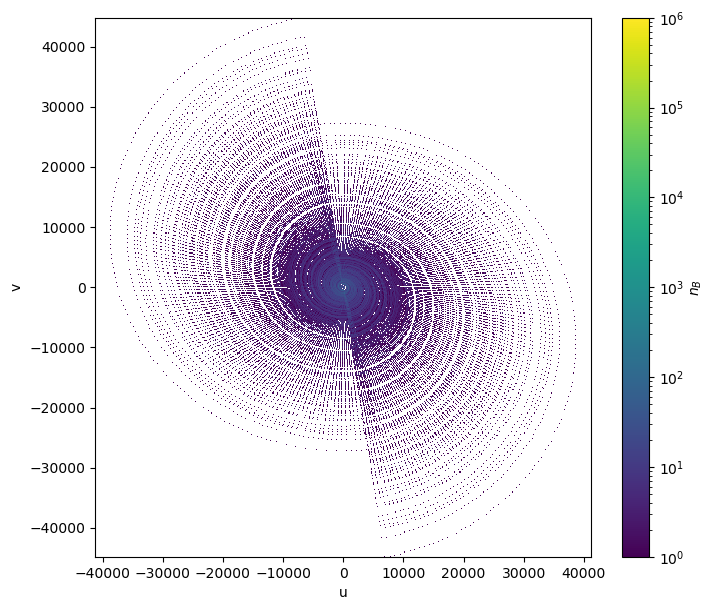

In [99]:
plot_uv_coverage_2(uvw, bins=512)

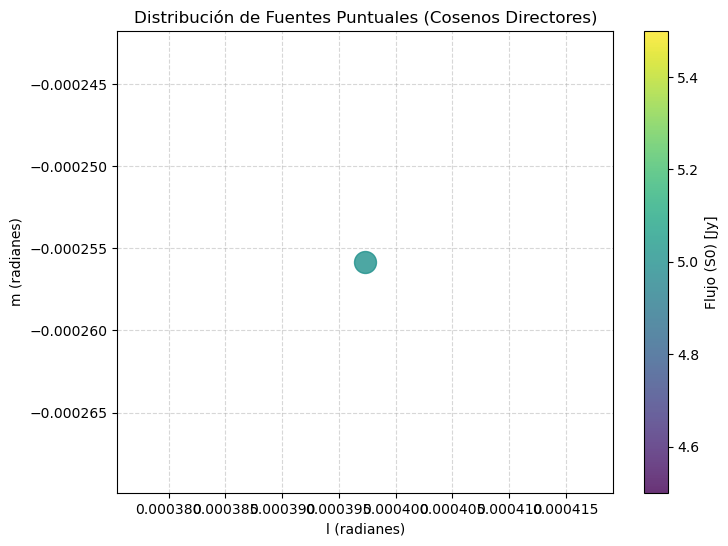

In [100]:
plot_sources(l,m,sources)

In [113]:
# cellsize = grid_config["pixel_size_image"]
cellsize = 0.00015
N = 128

coords = (np.arange(N) - N//2) * cellsize
l_grid, m_grid = np.meshgrid(coords, coords)

l_flat = l_grid.flatten()
m_flat = m_grid.flatten()

u = uvw_lambda[...,0]
v = uvw_lambda[...,1]

u_single = u[:,:,0].flatten()
v_single = v[:,:,0].flatten()
Vis = V[:,:,0].flatten()

Convergencia alcanzada en iteración 209


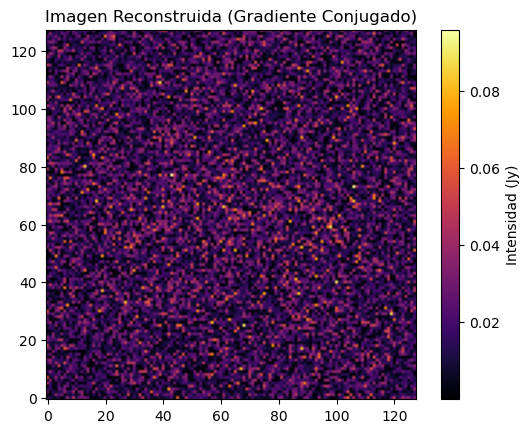

In [114]:
from modules.conj_grad import A, nonlinear_conjugate_gradient
import matplotlib.pyplot as plt

A_matrix = A(u_single, v_single, l_flat, m_flat)

imagen_reconstruida = nonlinear_conjugate_gradient(A_matrix, Vis, N, iterations=500, reg_lambda=0.01)

# Para visualizar (tomando la magnitud o parte real)
plt.imshow(np.abs(imagen_reconstruida), origin='lower', cmap='inferno')
plt.title("Imagen Reconstruida (Gradiente Conjugado)")
plt.colorbar(label='Intensidad (Jy)')
plt.show()